In [73]:
import matplotlib.pyplot as plt
import pandas as pd
%matplotlib inline
# Nasconde tutti i warning
%config InlineBackend.figure_format = 'retina'
%matplotlib inline
import warnings
warnings.filterwarnings('ignore')


# **Linguistic Pipeline in action 🦐**

Text_01_1115, St01_d **Il contadino astrologo**

In [9]:
with open ("C:\\Users\\schia\\OneDrive - Alma Mater Studiorum Università di Bologna\\Desktop\\IMT\\TESI\\linguistic_pipeline_EEG\\data\\texts_1115\\01_1115.txt", 'r', encoding="utf-8")as infile:
    text = infile.read()

print(text[:500])

Il contadino astrologo.
Un Re aveva perduto un anello prezioso. Cerca qua, cerca là, non si trova. Mise fuori un bando che
se un astrologo gli sa dire dov'è, lo fa ricco per tutta la vita. C'era un contadino senza un soldo, che non sapeva né leggere né scrivere, e si chiamava Gàmbara. "Sarà tanto difficile far l'astrologo? - si disse. – Mi ci voglio provare". E andò dal Re che lo prese in parola, e lo chiuse a studiare in una stanza. Dove c'erano solo un letto e un tavolo con un gran libraccio d


## **First Step**
*.py file* = `nlp_pipeline/processor.py`

- tokenization
- mwe
- lemmatization
- PoS
- Deapparse/Consituency
- **Zipf's frequency**
- **Type of words (*content, function*)**
- AoA

- **Statistics of texts**

In [10]:
df = pd.read_csv("C:\\Users\\schia\\OneDrive - Alma Mater Studiorum Università di Bologna\\Desktop\\IMT\\TESI\\linguistic_pipeline_EEG\\output\\output_1115\\01_1115\\01_1115.csv", sep=";", encoding="utf-8")
df.head(10)

,token_id,sentence_ids,tokens_no_punct,lemma_no_punct,PoS,depparse,head,constituency,AoA(m+sd),Zipf_freq,type_of_words
0,1,0,il,il,DET,det,contadino,(ROOT (f3 (sn (DET Il) (NOUN contadino) (sa (A...,NaN,"7,039560886",function
1,2,0,contadino,contadino,NOUN,root,ROOT,(ROOT (f3 (sn (DET Il) (NOUN contadino) (sa (A...,NaN,"3,787520326",content
2,3,0,astrologo,astrologo,ADJ,amod,contadino,(ROOT (f3 (sn (DET Il) (NOUN contadino) (sa (A...,NaN,"2,502677091",content
3,4,1,un,uno,DET,det,Re,(ROOT (f (sn (DET Un) (NOUN Re)) (ibar (AUX av...,NaN,"7,065833912",function
4,5,1,re,re,NOUN,nsubj,perduto,(ROOT (f (sn (DET Un) (NOUN Re)) (ibar (AUX av...,4.24 ± 1.76,"5,011715611",content
5,6,1,aveva,avere,AUX,aux,perduto,(ROOT (f (sn (DET Un) (NOUN Re)) (ibar (AUX av...,NaN,"5,632280537",function
6,7,1,perduto,perdere,VERB,root,ROOT,(ROOT (f (sn (DET Un) (NOUN Re)) (ibar (AUX av...,NaN,"4,078821718",content
7,8,1,un,uno,DET,det,anello,(ROOT (f (sn (DET Un) (NOUN Re)) (ibar (AUX av...,NaN,"7,065833912",function
8,9,1,anello,anello,NOUN,obj,perduto,(ROOT (f (sn (DET Un) (NOUN Re)) (ibar (AUX av...,NaN,"4,631517492",content
9,10,1,prezioso,prezioso,ADJ,amod,anello,(ROOT (f (sn (DET Un) (NOUN Re)) (ibar (AUX av...,NaN,"4,02438909",content


## **Statistics on the text**
*.py file* = `nlp_pipeline/processor.py`


In [ ]:
df = pd.read_csv("C:\\Users\\schia\\OneDrive - Alma Mater Studiorum Università di Bologna\\Desktop\\IMT\\TESI\\linguistic_pipeline_EEG\\output\\output_1115\\summary_all_texts.csv")

df.head(1)

,text_id,num_tokens,num_sentences,num_types,TTR,TTR_lemmas,avg_sentence_length,Zipf_mean,percent_rare_words,Gulpease_index,num_function_words,num_content_words,num_verbs,num_adjectives,num_nouns,top_lemmas,top_bigrams
0,01_1115,519,41,261,0.503,0.374,15.24,5.29,12.75,70.37,287 (55.3%),229 (44.1%),102 (19.7%),22 (4.2%),105 (20.2%),"['il (7.1%)', 'e (5.2%)', 'essere (4.4%)', 'un...","['l anello (0.8%)', 'e si (0.6%)', 'l astrolog..."



# <span style="color:#C8C8FF">**PREDICTORS**</span>
1. **Word Frequency**
2. **Lexical Surprisal**
3. **Lexical Entropy**
4. **Semantic Dissimilarity**
---
5. PoS Surprisal🤔


## **1. Word Frequency**

*.py file* = `nlp_pipeline/processor.py`

The **Zipf scale**: a standardized frequency measure.
To make the word frequency effect easier to understand, one need a scale with the following properties:
- it should be a logarithmic scale
- it should have relatively few points, without negative values
- the middle of the scale should separate the low-frequency words from the high-frequency words
- the scale should have a straightforward unit.

The Zipf scale is a **logarithmic scale** and goes from 1 to 7. 

**Zipf (w) = log10(fpmw) +3** or **Zipf(w) = log10(fpbw)**

*fpmw* = frequency per million words\
*fpbw* = frequency per billion words


[van Heuven WJ, Mandera P, Keuleers E, Brysbaert M. *SUBTLEX-UK: a new and improved word frequency database for British English*. Q J Exp Psychol (Hove). 2014;67(6):1176-90. doi: 10.1080/17470218.2013.850521. Epub 2014 Jan 13. PMID: 24417251]

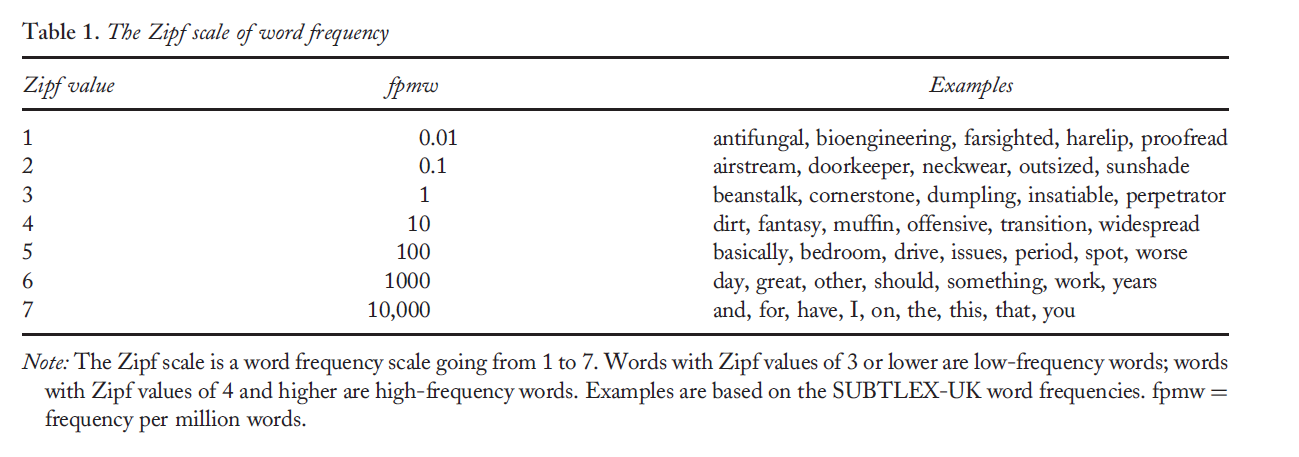

In [72]:
from IPython.display import Image
Image("C:\\Users\\schia\\OneDrive - Alma Mater Studiorum Università di Bologna\\Desktop\\IMT\\TESI\\linguistic_pipeline_EEG\\doc\\Zipffreq.png")

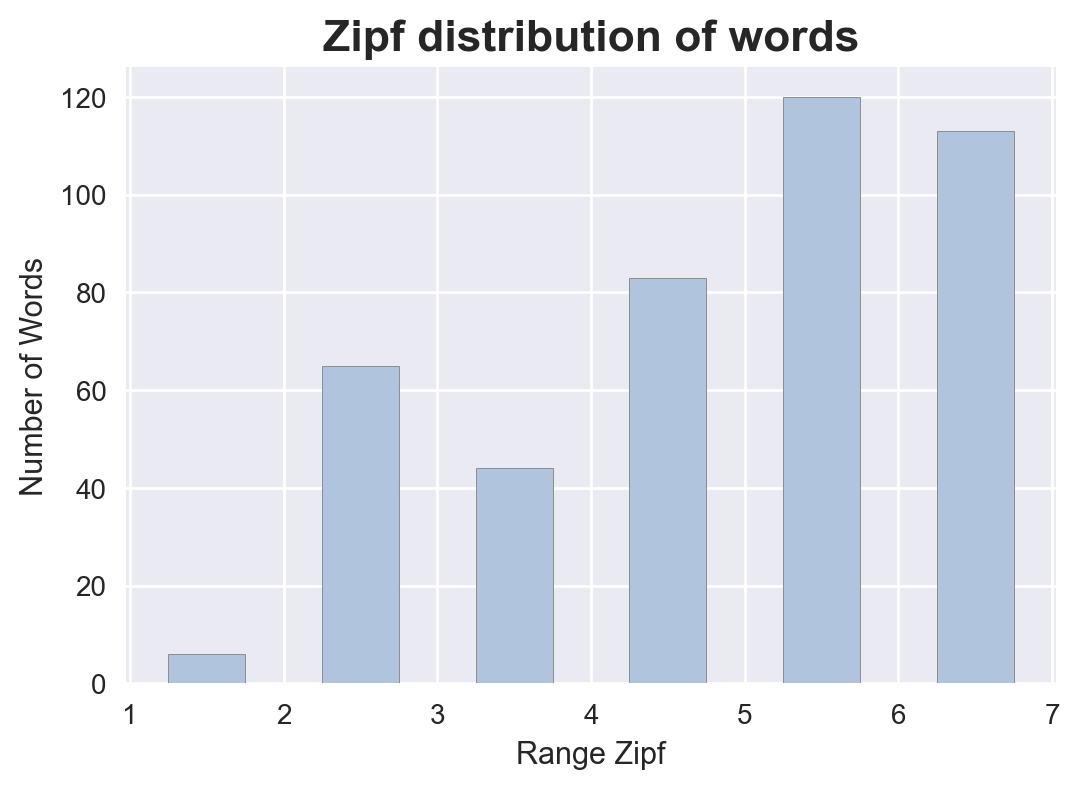

In [77]:
df = pd.read_csv("C:\\Users\\schia\\OneDrive - Alma Mater Studiorum Università di Bologna\\Desktop\\IMT\\TESI\\linguistic_pipeline_EEG\\output\\output_1115\\01_1115\\01_1115.csv", sep=";", encoding="utf-8")
df["Zipf_freq"] = df["Zipf_freq"].str.replace(',', '.').astype(float)

# Definizione dei bin
bins = [1, 2, 3, 4, 5, 6, 7, float("inf")]

plt.figure(figsize=(6, 4))
plt.style.use("seaborn-v0_8")
plt.hist(df["Zipf_freq"], bins=bins, color="lightsteelblue", rwidth=0.5, edgecolor="gray")
plt.xlabel("Range Zipf")
plt.ylabel("Number of Words")
plt.title("Zipf distribution of words", fontsize=16, fontweight="bold")
plt.show()


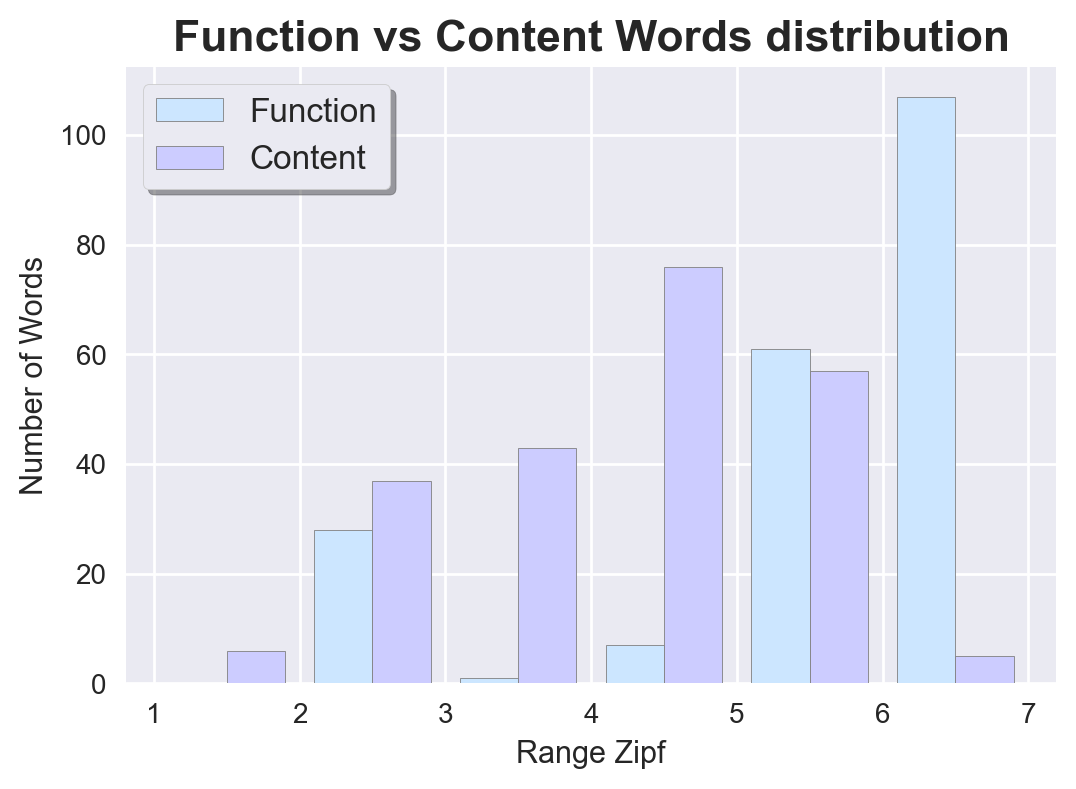

In [78]:
df_funzione = df[df["type_of_words"] == "function"]
df_contenuto = df[df["type_of_words"] == "content"]
plt.figure(figsize=(6, 4))

plt.hist(
    [df_funzione["Zipf_freq"], df_contenuto["Zipf_freq"]],
    bins=bins,
    color=[(204/255, 230/255, 255/255), (204/255, 204/255, 255/255)],
    label=["Function", "Content"], edgecolor="gray")

plt.xlabel("Range Zipf")
plt.ylabel("Number of Words")
plt.legend(fontsize=12, frameon=True, shadow=True)
plt.title("Function vs Content Words distribution", fontsize=16, fontweight="bold")
plt.show()


## **3. Lexical Entropy**

*.py file* = `nlp_pipeline/surprisal_entropy.py`


## **4. Semantic Dissimilarity**
*.py file* = `nlp_pipeline/semantic_dissimilarity.py`
